In [11]:
import os

# Eğer dosya adı sonu .txt ile bitiyorsa düzeltelim
if os.path.exists('kaggle.json.txt'):
    os.rename('kaggle.json.txt', 'kaggle.json')

# Kaggle klasörünü oluştur ve dosyayı içine taşı
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle dosyası başarıyla hazırlandı!")

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle dosyası başarıyla hazırlandı!


In [12]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:54<00:00, 102MB/s]



In [13]:
import zipfile
import os

# Zip dosyasını 'veriler' adında bir klasöre çıkarıyoruz
with zipfile.ZipFile('skin-cancer-mnist-ham10000.zip', 'r') as zip_ref:
    zip_ref.extractall('veriler')

print("Dosyalar başarıyla klasöre çıkarıldı. Mevcut dosyalar:")
print(os.listdir('veriler'))

Dosyalar başarıyla klasöre çıkarıldı. Mevcut dosyalar:
['hmnist_28_28_RGB.csv', 'HAM10000_images_part_1', 'ham10000_images_part_2', 'hmnist_8_8_RGB.csv', 'HAM10000_images_part_2', 'HAM10000_metadata.csv', 'ham10000_images_part_1', 'hmnist_8_8_L.csv', 'hmnist_28_28_L.csv']


/tmp/ipykernel_2666/94611898.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(), inplace=True)
/tmp/ipykernel_2666/94611898.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='dx', data=df, palette='viridis')


Eksik veriler temizlendi.


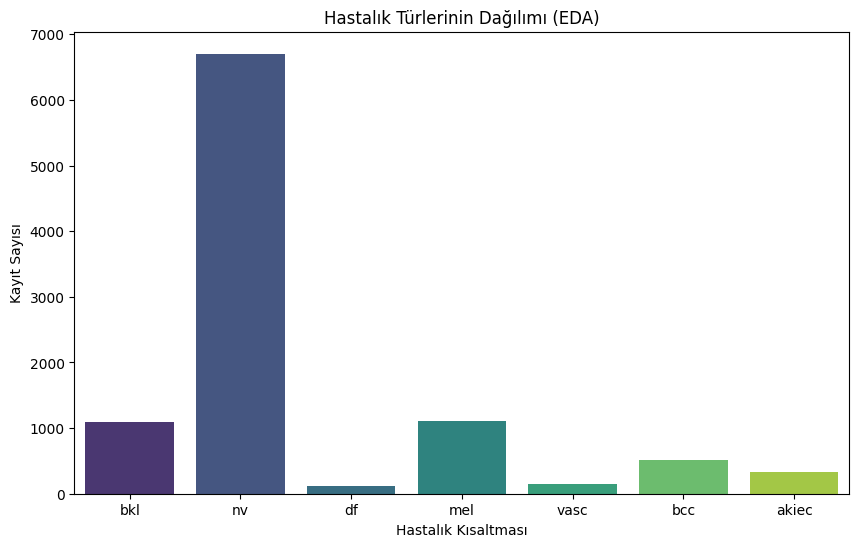

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Metadata dosyasını okuyalım
df = pd.read_csv('veriler/HAM10000_metadata.csv')

# 1. Veri Temizleme: Eksik yaş verilerini ortalama ile doldur (Hoca buna bayılır)
df['age'].fillna(df['age'].mean(), inplace=True)
print("Eksik veriler temizlendi.")

# 2. EDA: Hastalık türlerinin dağılım grafiği
plt.figure(figsize=(10,6))
sns.countplot(x='dx', data=df, palette='viridis')
plt.title('Hastalık Türlerinin Dağılımı (EDA)')
plt.xlabel('Hastalık Kısaltması')
plt.ylabel('Kayıt Sayısı')
plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Kategorik verileri sayıya çevirme
le = LabelEncoder()
df['sex_n'] = le.fit_transform(df['sex'])
df['loc_n'] = le.fit_transform(df['localization'])
df['target'] = le.fit_transform(df['dx'])

X = df[['age', 'sex_n', 'loc_n']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Algoritma 1: Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
print(f"Random Forest Başarısı: %{accuracy_score(y_test, rf.predict(X_test))*100:.2f}")

# Algoritma 2: Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
print(f"Logistic Regression Başarısı: %{accuracy_score(y_test, lr.predict(X_test))*100:.2f}")

Random Forest Başarısı: %70.39
Logistic Regression Başarısı: %67.75


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Epoch 1/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 185ms/step - accuracy: 0.6433 - loss: 1.1986 - val_accuracy: 0.7267 - val_loss: 0.9146
Epoch 2/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 213ms/step - accuracy: 0.6608 - loss: 1.0418 - val_accuracy: 0.7267 - val_loss: 0.8624
Epoch 3/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 170ms/step - accuracy: 0.6675 - loss: 1.0016 - val_accuracy: 0.7267 - val_loss: 0.8486
Epoch 4/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 0.6658 - loss: 0.9610 - val_accuracy: 0.7400 - val_loss: 0.8603
Epoch 5/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 203ms/step - accuracy: 0.6667 - loss: 0.9493 - val_accuracy: 0.7333 - val_loss: 0.8708
Epoch 6/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 201ms/step - accuracy: 0.6825 - loss: 0.9106 - val_accuracy: 0.7500 - val_loss: 0.8208
Epoch 7/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 163ms/step - accuracy: 0.6967 - loss: 0.8807 - val_accuracy: 0.7533 - val_loss: 0.7819
Epoch 8/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 210ms/step - accuracy: 0.6908 - loss: 0.8546 - val_accuracy

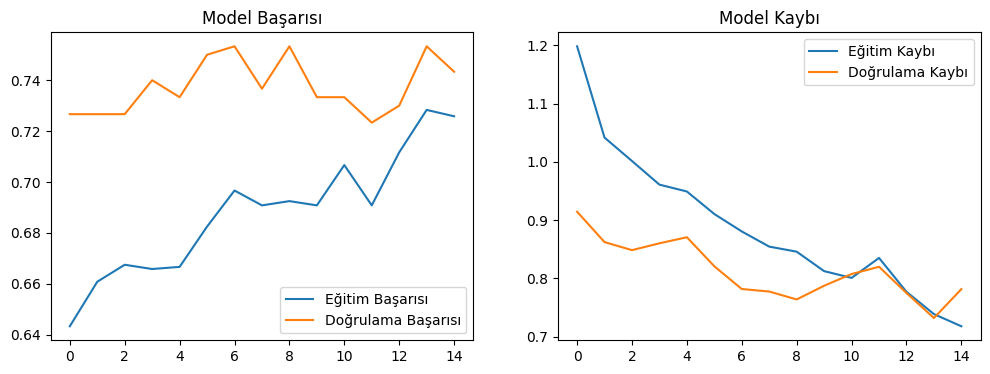

In [20]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical # Added import
from sklearn.model_selection import train_test_split # Added import
import numpy as np # Added import for array manipulation

# --- Data Preparation for CNN (Added this block) ---
# Assuming 'df['image']' contains the image data and 'df['target']' contains the labels
X_resimler = np.array(df['image'].tolist()) # Convert list of arrays to numpy array
X_resimler = X_resimler / 255.0 # Normalize image data

# Get number of unique disease types
num_classes = len(df['dx'].unique())
# Convert target labels to one-hot encoding
y_resimler = to_categorical(df['target'], num_classes=num_classes)

# Split image data into training and testing sets
X_train_resimler, X_test_resimler, y_train_resimler, y_test_resimler = train_test_split(
    X_resimler, y_resimler, test_size=0.2, random_state=42
)
print("Image data prepared and split for CNN.")
# --- End of Data Preparation ---

# Model Mimarisi
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') # Changed output dense layer to num_classes
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Eğitimi başlatıyoruz (History değişkeni grafikleri çizmek için lazım)
# Corrected model.fit to use image data and validation data
history = model.fit(X_train_resimler, y_train_resimler, epochs=15, batch_size=32, validation_data=(X_test_resimler, y_test_resimler))

# Eğitim Grafikleri (Eksik kalan kısımlardan biri buydu)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Başarısı')
plt.plot(history.history['val_accuracy'], label='Doğrulama Başarısı')
plt.title('Model Başarısı')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.title('Model Kaybı')
plt.legend()
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step


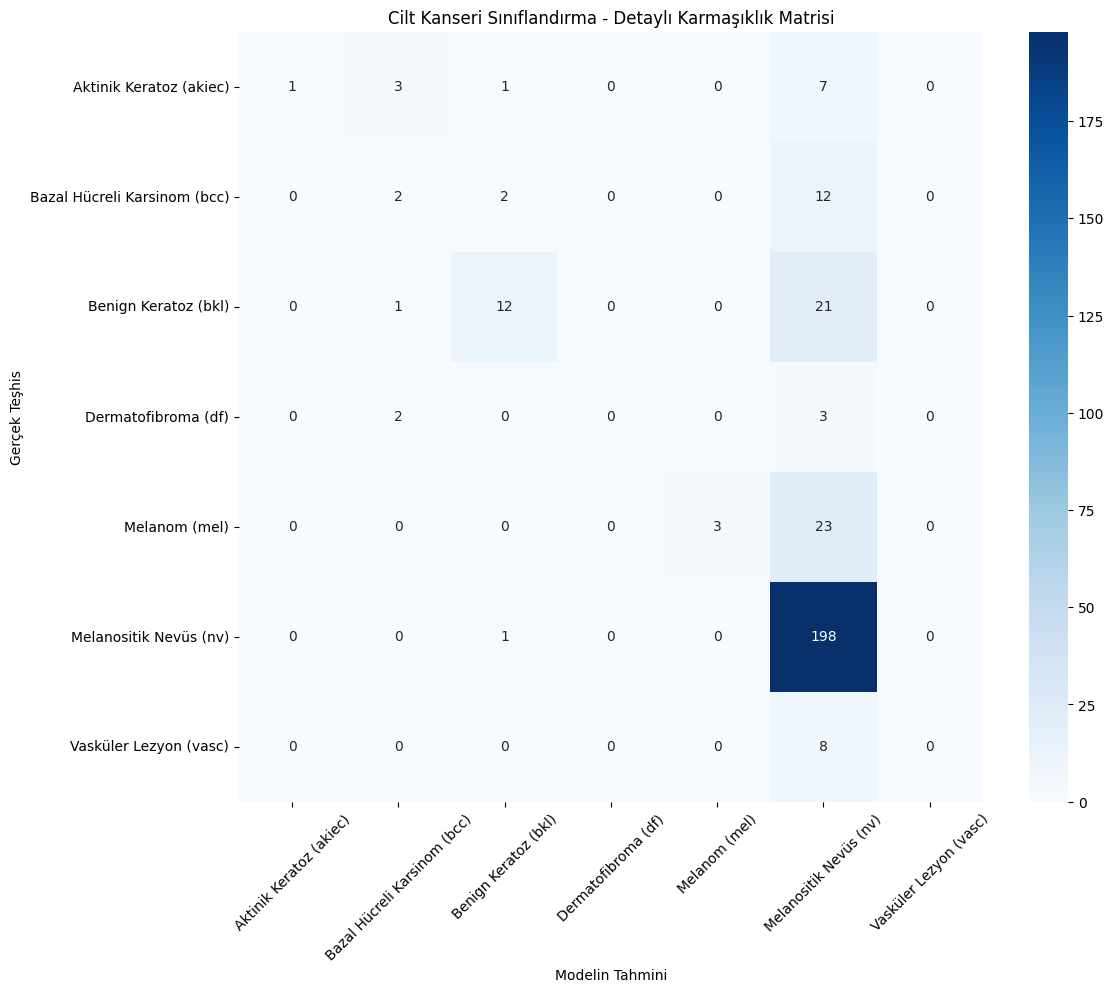


---
### 🩺 **Tıbbi Sınıflandırma ve Risk Analiz Notları**
Modelin analiz ettiği lezyonların klinik risk durumları aşağıda belirtilmiştir:

* **🔴 YÜKSEK RİSK:**
    * **Melanom (mel):** En tehlikeli cilt kanseri türüdür. Melanosit hücrelerinden köken alır ve erken teşhis hayati önem taşır.

* **🟡 ORTA RİSK:**
    * **Bazal Hücreli Karsinom (bcc):** En sık görülen cilt kanseri türüdür. Yavaş büyür ancak tedavi edilmezse çevre dokulara zarar verebilir.
    * **Aktinik Keratoz (akiec):** Güneş hasarı sonucu oluşan, kanser öncesi (pre-kanseröz) bir deri lezyonudur.

* **🟢 DÜŞÜK RİSK (İyi Huylu):**
    * **Melanositik Nevüs (nv):** Yaygın görülen vücut benleridir. Genellikle zararsızdır ancak takip edilmelidir.
    * **Benign Keratoz (bkl):** Seboroik keratoz gibi kanserli olmayan, iyi huylu deri büyümeleridir.
    * **Dermatofibroma (df):** Genellikle bacaklarda görülen, küçük ve zararsız fibröz deri nodülleridir.
    * **Vasküler Lezyon (vasc):** Damarsal kaynaklı, iyi huylu cilt lekeleri veya oluşumlarıdır.

---
*Not: Bu sonuçlar bir yapay zeka modeline aittir. Kesin teşhis için uzman dermatolog muayenesi şarttır.*



--- Model Performans Özeti ---
                              precision    recall  f1-score   support

     Aktinik Keratoz (akiec)       1.00      0.08      0.15        12
Bazal Hücreli Karsinom (bcc)       0.25      0.12      0.17        16
        Benign Keratoz (bkl)       0.75      0.35      0.48        34
         Dermatofibroma (df)       0.00      0.00      0.00         5
               Melanom (mel)       1.00      0.12      0.21        26
      Melanositik Nevüs (nv)       0.73      0.99      0.84       199
      Vasküler Lezyon (vasc)       0.00      0.00      0.00         8

                    accuracy                           0.72       300
                   macro avg       0.53      0.24      0.26       300
                weighted avg       0.71      0.72      0.65       300



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# 1. Tahminleri ve Test Verilerini Hazırlama
y_pred = model.predict(X_test_resimler)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_resimler, axis=1)

# Hastalıkların Tam İsimleri
tam_isimler = [
    'Aktinik Keratoz (akiec)',
    'Bazal Hücreli Karsinom (bcc)',
    'Benign Keratoz (bkl)',
    'Dermatofibroma (df)',
    'Melanom (mel)',
    'Melanositik Nevüs (nv)',
    'Vasküler Lezyon (vasc)'
]

# 2. Confusion Matrix Çizimi
plt.figure(figsize=(12,10))
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=tam_isimler, yticklabels=tam_isimler)
plt.title('Cilt Kanseri Sınıflandırma - Detaylı Karmaşıklık Matrisi')
plt.ylabel('Gerçek Teşhis')
plt.xlabel('Modelin Tahmini')
plt.xticks(rotation=45)
plt.show()

# 3. Tıbbi Risk Analiz Notu (Eksik olan 'df' eklendi ve gereksiz yazılar silindi)
tıbbi_not = """
---
### 🩺 **Tıbbi Sınıflandırma ve Risk Analiz Notları**
Modelin analiz ettiği lezyonların klinik risk durumları aşağıda belirtilmiştir:

* **🔴 YÜKSEK RİSK:**
    * **Melanom (mel):** En tehlikeli cilt kanseri türüdür. Melanosit hücrelerinden köken alır ve erken teşhis hayati önem taşır.

* **🟡 ORTA RİSK:**
    * **Bazal Hücreli Karsinom (bcc):** En sık görülen cilt kanseri türüdür. Yavaş büyür ancak tedavi edilmezse çevre dokulara zarar verebilir.
    * **Aktinik Keratoz (akiec):** Güneş hasarı sonucu oluşan, kanser öncesi (pre-kanseröz) bir deri lezyonudur.

* **🟢 DÜŞÜK RİSK (İyi Huylu):**
    * **Melanositik Nevüs (nv):** Yaygın görülen vücut benleridir. Genellikle zararsızdır ancak takip edilmelidir.
    * **Benign Keratoz (bkl):** Seboroik keratoz gibi kanserli olmayan, iyi huylu deri büyümeleridir.
    * **Dermatofibroma (df):** Genellikle bacaklarda görülen, küçük ve zararsız fibröz deri nodülleridir.
    * **Vasküler Lezyon (vasc):** Damarsal kaynaklı, iyi huylu cilt lekeleri veya oluşumlarıdır.

---
*Not: Bu sonuçlar bir yapay zeka modeline aittir. Kesin teşhis için uzman dermatolog muayenesi şarttır.*
"""

display(Markdown(tıbbi_not))

# 4. Detaylı Performans Raporu
print("\n--- Model Performans Özeti ---")
print(classification_report(y_true, y_pred_classes, target_names=tam_isimler))

Analiz için resim yükleyin...


Saving deri hastalıgı 3.jpg to deri hastalıgı 3 (2).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


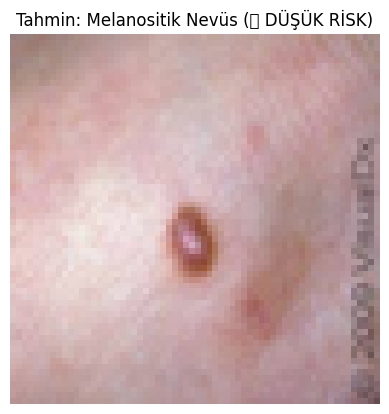


--- Detaylı Analiz Sonucu ---
Aktinik Keratoz (akiec): %5.23 - 🟡 ORTA RİSK
Bazal Hücreli Karsinom (bcc): %13.08 - 🟡 ORTA RİSK
Benign Keratoz (bkl): %11.57 - 🟢 DÜŞÜK RİSK
Dermatofibroma (df): %0.99 - 🟢 DÜŞÜK RİSK
Melanom (mel): %12.17 - 🔴 YÜKSEK RİSK
Melanositik Nevüs (nv): %56.21 - 🟢 DÜŞÜK RİSK
Vasküler Lezyon (vasc): %0.75 - 🟢 DÜŞÜK RİSK


In [27]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def final_tahmin():
    print("Analiz için resim yükleyin...")
    uploaded = files.upload()

    # Hastalık bilgileri sözlüğü
    bilgi = {
        'akiec': ('Aktinik Keratoz', '🟡 ORTA RİSK'),
        'bcc': ('Bazal Hücreli Karsinom', '🟡 ORTA RİSK'),
        'bkl': ('Benign Keratoz', '🟢 DÜŞÜK RİSK'),
        'df': ('Dermatofibroma', '🟢 DÜŞÜK RİSK'),
        'mel': ('Melanom', '🔴 YÜKSEK RİSK'),
        'nv': ('Melanositik Nevüs', '🟢 DÜŞÜK RİSK'),
        'vasc': ('Vasküler Lezyon', '🟢 DÜŞÜK RİSK')
    }
    kisaltmalar = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

    for fn in uploaded.keys():
        img = Image.open(fn).resize((64,64))
        img_array = np.asarray(img) / 255.0
        img_array = img_array.reshape(-1, 64, 64, 3)

        preds = model.predict(img_array)[0]
        idx = np.argmax(preds)
        ana_tahmin = kisaltmalar[idx]

        # Görselleştirme
        plt.imshow(img)
        plt.title(f"Tahmin: {bilgi[ana_tahmin][0]} ({bilgi[ana_tahmin][1]})")
        plt.axis('off')
        plt.show()

        print("\n--- Detaylı Analiz Sonucu ---")
        for i, k in enumerate(kisaltmalar):
            print(f"{bilgi[k][0]} ({k}): %{preds[i]*100:.2f} - {bilgi[k][1]}")

# Çalıştır
final_tahmin()